In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import seaborn as sns
import pandas as pd
import numpy as np
import kagglehub
import torch
import os

path = kagglehub.dataset_download("nikhilbhathi/data-scientist-salary-us-glassdoor")

df = pd.read_csv(os.path.join(path, "data_cleaned_2021.csv"))
df.head()

Using Colab cache for faster access to the 'data-scientist-salary-us-glassdoor' dataset.


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


EDA

In [ ]:
# Data Type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               742 non-null    int64  
 1   Job Title           742 non-null    object 
 2   Salary Estimate     742 non-null    object 
 3   Job Description     742 non-null    object 
 4   Rating              742 non-null    float64
 5   Company Name        742 non-null    object 
 6   Location            742 non-null    object 
 7   Headquarters        742 non-null    object 
 8   Size                742 non-null    object 
 9   Founded             742 non-null    int64  
 10  Type of ownership   742 non-null    object 
 11  Industry            742 non-null    object 
 12  Sector              742 non-null    object 
 13  Revenue             742 non-null    object 
 14  Competitors         742 non-null    object 
 15  Hourly              742 non-null    int64  
 16  Employer

In [ ]:
# Value Of Data
df.describe()

,index,Rating,Founded,Hourly,Employer provided,Lower Salary,Upper Salary,Avg Salary(K),Age,Python,...,keras,pytorch,scikit,tensor,hadoop,tableau,bi,flink,mongo,google_an
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,...,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,469.129380,3.618868,1837.154987,0.032345,0.022911,74.754717,128.214286,101.484501,47.524259,0.528302,...,0.039084,0.052561,0.072776,0.097035,0.167116,0.199461,0.075472,0.013477,0.049865,0.018868
std,279.793117,0.801210,497.183763,0.177034,0.149721,30.945892,45.128650,37.482449,53.839080,0.499535,...,0.193925,0.223305,0.259944,0.296205,0.373331,0.399865,0.264329,0.115384,0.217813,0.136150
min,0.000000,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,15.500000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,221.500000,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,12.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,472.500000,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,25.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,707.750000,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,60.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,955.000000,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,277.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Empty Data
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Duplicated Data
df.duplicated().sum()

np.int64(0)

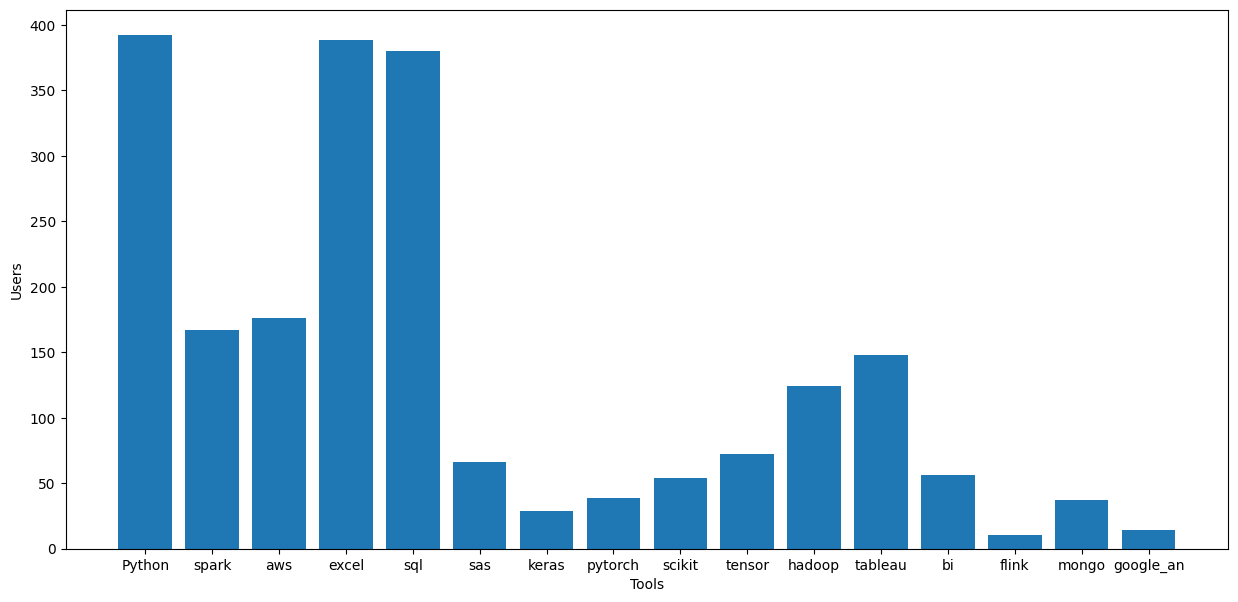

In [ ]:
# The Most Users Using A Tools
columns = [df.columns[i] for i in range(23, 39)]
data = [df[i].sum() for i in columns]
plt.figure(figsize=(15, 7))
plt.bar(columns, data)
plt.ylabel("Users")
plt.xlabel("Tools")
plt.show()

In [ ]:
# Degree Education
df["Degree"].value_counts()

,count
Degree,
na,383
M,252
P,107


In [ ]:
# Choose The Target
y = df['Avg Salary(K)']

# Dump The Columns That Have Any Probability Of Data Leakage And Unnecessary
X_raw =  df.drop(columns=['Avg Salary(K)', 'index', 'Salary Estimate', 'Job Description', 'company_txt', 'Competitors'])

# Seperate The Data With The Type Of Data Object And Number
cat_cols = X_raw.select_dtypes(include=["object"]).columns.to_list()
num_cols = X_raw.select_dtypes(exclude=["object"]).columns.to_list()
print("Category Columns:", cat_cols)
print("Number Columns:", num_cols)

Category Columns: ['Job Title', 'Company Name', 'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Job Location', 'job_title_sim', 'seniority_by_title', 'Degree']
Number Columns: ['Rating', 'Founded', 'Hourly', 'Employer provided', 'Lower Salary', 'Upper Salary', 'Age', 'Python', 'spark', 'aws', 'excel', 'sql', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an']


In [ ]:
# Changing Categorical Data Type to Numerical
ord = OrdinalEncoder()
X_cat = ord.fit_transform(X_raw[cat_cols])

In [ ]:
# Transforming Numeric Data By Scaling It To Flatten Numbers So That Large Numbers In Training Data Do Not Affect Deep Learning Training
scl = StandardScaler()
X_num = scl.fit_transform(X_raw[num_cols])

In [ ]:
# Recombining And Splitting With Train Data And Test Data
# The nn.Embedding layer in PyTorch only accepts the LongTensor (64-bit integer) data type. If you enter a FloatTensor (decimal), PyTorch will throw an error.
X_cat_tensor = torch.LongTensor(X_cat)      # Integer For Embedding
X_num_tensor = torch.FloatTensor(X_num)    # Float For Linear Layer

X_train_cat, X_test_cat, _, _ = train_test_split(
    X_cat_tensor, y, test_size=0.2, random_state=42
    )
X_train_num, X_test_num, y_train_split, y_test_split = train_test_split(
    X_num_tensor, y, test_size=0.2, random_state=42
    )

Y_train = torch.FloatTensor(y_train_split.values).unsqueeze(1)
Y_test = torch.FloatTensor(y_test_split.values).unsqueeze(1)

In [ ]:
class EmbeddingSalaryPredictor(nn.Module):
    def __init__(self, embedding_sizes:list[tuple[int, int]], num_numerical_cols:int, dropout_rate=0.3):
        super(EmbeddingSalaryPredictor, self).__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_classes, emb_dim) for num_classes, emb_dim in embedding_sizes
        ])

        total_emb_dim = sum(emb_dim for _, emb_dim in embedding_sizes)
        total_input_dim = total_emb_dim + num_numerical_cols

        # --- Hidden Layers 1 ---
        self.fc1 = nn.Linear(total_input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(p=dropout_rate)

        # --- Hidden Layers 2 ---
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(p=0.2)

        # --- Output Layers ---
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x_cat, x_num):
            embedded_cols = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)]
            x_cat_emb = torch.cat(embedded_cols, dim=1)
            x = torch.cat([x_cat_emb, x_num], dim=1)

            # --- Layer 1 ---
            x = self.fc1(x)
            x = self.bn1(x)
            x = self.relu1(x)
            x = self.drop1(x)

            # --- Layer 2 ---
            x = self.fc2(x)
            x = self.bn2(x)
            x = self.relu2(x)
            x = self.drop2(x)

            # --- Output Layer ---
            x = self.output_layer(x)
            return x

In [ ]:
num_unique_cats = [len(ord.categories_[i]) for i in range(len(cat_cols))]
print("Jumlah unik tiap kolom kategorikal:", num_unique_cats)

Jumlah unik tiap kolom kategorikal: [264, 343, 200, 198, 8, 9, 60, 25, 13, 37, 10, 3, 3]


In [ ]:
embedding_sizes = []
for num_classes in num_unique_cats:
    emb_dim = max(1, min(50, num_classes // 2))
    embedding_sizes.append((num_classes, emb_dim))

num_numerical_cols = X_train_num.shape[1]

model = EmbeddingSalaryPredictor(embedding_sizes, num_numerical_cols)
print(model)

EmbeddingSalaryPredictor(
  (embeddings): ModuleList(
    (0): Embedding(264, 50)
    (1): Embedding(343, 50)
    (2): Embedding(200, 50)
    (3): Embedding(198, 50)
    (4): Embedding(8, 4)
    (5): Embedding(9, 4)
    (6): Embedding(60, 30)
    (7): Embedding(25, 12)
    (8): Embedding(13, 6)
    (9): Embedding(37, 18)
    (10): Embedding(10, 5)
    (11-12): 2 x Embedding(3, 1)
  )
  (fc1): Linear(in_features=304, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
criterion = nn.MSELoss()

optimezer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 500

for epoch in range(epochs):
    y_pred = model(X_train_cat, X_train_num)

    loss = criterion(y_pred, Y_train)

    optimezer.zero_grad()

    loss.backward()

    optimezer.step()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch: [{epoch+1}/{epochs}], Loss MSE: {loss.item():.4f}')

Epoch: [50/500], Loss MSE: 8280.5508
Epoch: [100/500], Loss MSE: 2516.0623
Epoch: [150/500], Loss MSE: 216.2079
Epoch: [200/500], Loss MSE: 203.1012
Epoch: [250/500], Loss MSE: 183.3326
Epoch: [300/500], Loss MSE: 182.1194
Epoch: [350/500], Loss MSE: 170.9950
Epoch: [400/500], Loss MSE: 161.5310
Epoch: [450/500], Loss MSE: 146.7046
Epoch: [500/500], Loss MSE: 160.4582


In [ ]:
# Wajib dipanggil! Mematikan Dropout dan mengunci BatchNorm
model.eval()

# Matikan mesin pelacak gradien agar hemat memori RAM
with torch.no_grad():
    # Tebak gaji menggunakan data test
    y_test_pred = model(X_test_cat, X_test_num)

    # Hitung seberapa jauh melesetnya menggunakan metrik MAE atau MSE
    test_loss = criterion(y_test_pred, Y_test)

    print(f"Evaluasi Model Selesai!")
    print(f"Test Loss (MSE): {test_loss.item():.4f}")

    # Contoh melihat 5 prediksi pertama vs aslinya
    print("\nPerbandingan 5 Data Pertama:")
    for i in range(5):
        gaji_asli = Y_test[i].item()
        gaji_tebakan = y_test_pred[i].item()
        print(f"Asli: ${gaji_asli:.1f}K | Tebakan: ${gaji_tebakan:.1f}K")

Evaluasi Model Selesai!
Test Loss (MSE): 100.0726

Perbandingan 5 Data Pertama:
Asli: $100.5K | Tebakan: $104.7K
Asli: $48.5K | Tebakan: $47.3K
Asli: $154.5K | Tebakan: $156.3K
Asli: $122.0K | Tebakan: $117.7K
Asli: $162.0K | Tebakan: $158.7K


In [ ]:
# 1. WAJIB: Kunci model ke mode evaluasi (Mematikan Dropout & menstabilkan BatchNorm)
model.eval()

# 2. Matikan penghitungan gradien
with torch.no_grad():
    # Masukkan data uji (Test Data)
    y_test_pred = model(X_test_cat, X_test_num)

    # Hitung nilai Error (MSE dan RMSE) pada data uji
    test_mse = criterion(y_test_pred, Y_test)
    test_rmse = torch.sqrt(test_mse)

    print("=== HASIL EVALUASI DATA TEST ===")
    print(f"Test MSE  : {test_mse.item():.4f}")
    print(f"Test RMSE : {test_rmse.item():.4f}")

    print("\n--- Perbandingan 5 Prediksi Pertama ---")
    for i in range(5):
        asli = Y_test[i].item()
        tebakan = y_test_pred[i].item()
        selisih = abs(asli - tebakan)
        print(f"Gaji Asli: ${asli:.1f}K | Tebakan Model: ${tebakan:.1f}K | Meleset: ${selisih:.1f}K")

=== HASIL EVALUASI DATA TEST ===
Test MSE  : 100.0726
Test RMSE : 10.0036

--- Perbandingan 5 Prediksi Pertama ---
Gaji Asli: $100.5K | Tebakan Model: $104.7K | Meleset: $4.2K
Gaji Asli: $48.5K | Tebakan Model: $47.3K | Meleset: $1.2K
Gaji Asli: $154.5K | Tebakan Model: $156.3K | Meleset: $1.8K
Gaji Asli: $122.0K | Tebakan Model: $117.7K | Meleset: $4.3K
Gaji Asli: $162.0K | Tebakan Model: $158.7K | Meleset: $3.3K
